In [1]:
import tensorflow as tf

mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 정규화(normalization) 단계, 픽셀 값을 0~255에서 0.0~1.0 범위로 정규화
# 픽셀은 8비트로 저장되어 최대값이 255, 이를 255로 나누어 0은 0.0(검정), 255는 1.0(흰색)으로 정규화
# 정규화 하는 이유
# - 입력값이 크먄 기중치 곱의 결과도 커져서 기울기가 불안정해지고 학습이 잘 안됨
# - 입력 범위가 작고 일정하면 옵티마이저가 적절한 보폭으로 안정적으로 수렴
# - 0~255 범위를 그대로 넣어도 작동은 하지만 정확도나 낮을 수 있고 학습 시간이 늘어나게 됨
x_train, x_test = x_train / 255.0, x_test / 255.0

I0000 00:00:1790656917.045553  576928 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790656917.045864  576928 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1790656917.071296  576928 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790656917.909245  576928 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
print(x_train.shape, x_train.dtype, x_train.min(), x_train.max())
print(y_train[:10])

(60000, 28, 28) float64 0.0 1.0
[5 0 4 1 9 2 1 3 1 4]


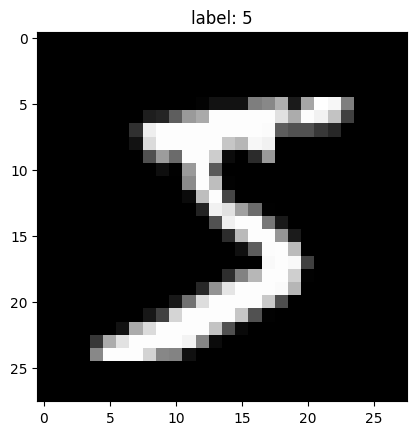

In [3]:
import matplotlib.pyplot as plt
plt.imshow(x_train[0], cmap="gray")
plt.title(f"label: {y_train[0]}")
plt.show()

In [4]:
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(1000, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
)

model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

/home/sado/venv/ml/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1790656919.053361  576928 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:50



In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,010 (3.03 MB)

 Trainable params: 795,010 (3.03 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
import time

start_time = time.time()
hist = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=100,
    verbose=1,
)

print("Fit time: ", time.time() - start_time)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9357 - loss: 0.2212 - val_accuracy: 0.9674 - val_loss: 0.1073
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9746 - loss: 0.0865 - val_accuracy: 0.9752 - val_loss: 0.0809
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9844 - loss: 0.0528 - val_accuracy: 0.9776 - val_loss: 0.0703
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9908 - loss: 0.0335 - val_accuracy: 0.9796 - val_loss: 0.0666
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9944 - loss: 0.0222 - val_accuracy: 0.9806 - val_loss: 0.0648
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9963 - loss: 0.0160 - val_accuracy: 0.9774 - val_loss: 0.0779
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9970 - loss: 0.0121 - val_accuracy: 0.9786 - val_loss: 0.0774
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9972 - loss: 0.0107 - val_accuracy: 0.

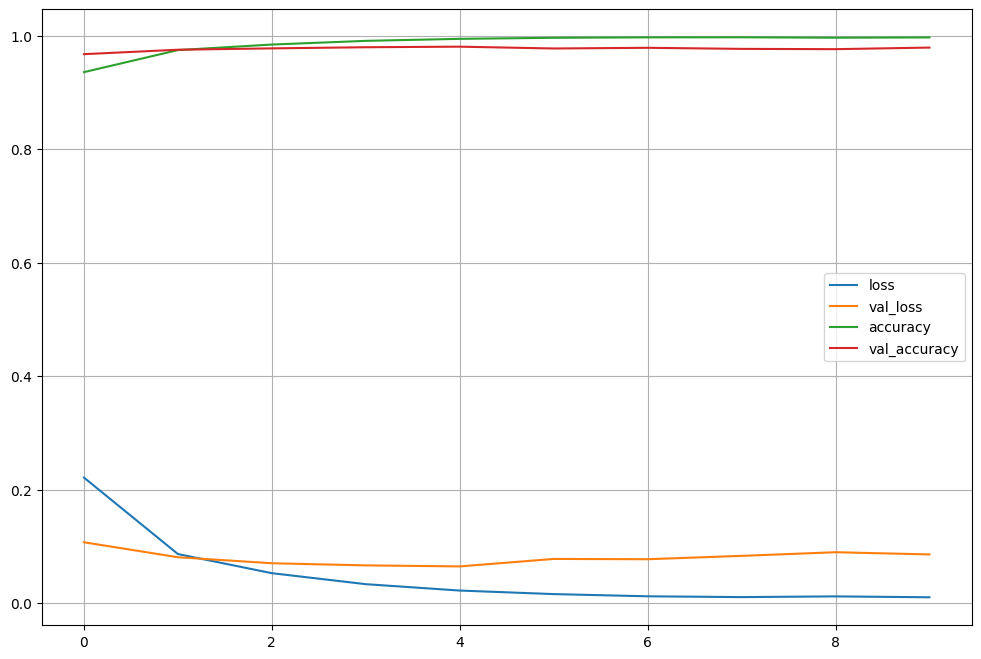

In [9]:
import matplotlib.pyplot as plt

plot_target = ["loss", "val_loss", "accuracy", "val_accuracy"]

plt.figure(figsize=(12, 8))

for each in plot_target:
    plt.plot(hist.history[each], label=each)

plt.legend()
plt.grid()
plt.show()

In [10]:
score = model.evaluate(x_test, y_test)
print("Test loss: ", score[0])
print("Test accuracy: ", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - accuracy: 0.9790 - loss: 0.0859
Test loss:  0.08587835729122162
Test accuracy:  0.9789999723434448


In [12]:
import numpy as np

predicted_result = model.predict(x_test)
predicted_labels = np.argmax(predicted_result, axis=1)
predicted_labels[:10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step


array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])

In [13]:
y_test[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

In [14]:
wrong_result = []

for n in range(0, len(y_test)):
    if predicted_labels[n] != y_test[n]:
        wrong_result.append(n)

len(wrong_result)

210

In [16]:
import random

samples = random.choices(population=wrong_result, k=16)
samples

[3604,
 4425,
 4201,
 1681,
 619,
 4534,
 1609,
 4201,
 2098,
 2720,
 445,
 2597,
 3906,
 1609,
 582,
 965]

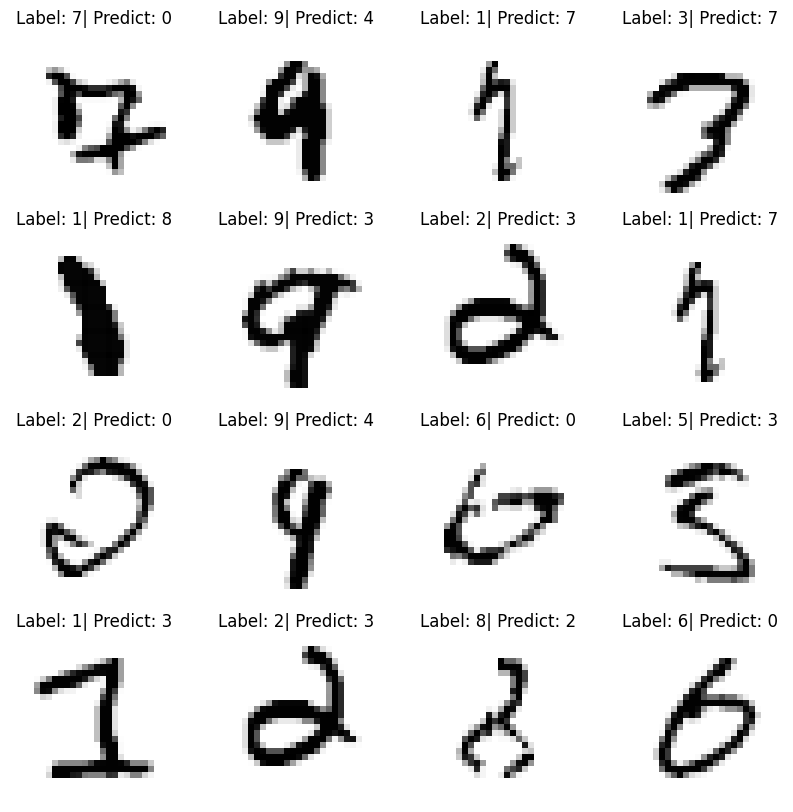

In [17]:
plt.figure(figsize=(10, 10))

for idx, n in enumerate(samples):
    plt.subplot(4, 4, idx + 1)
    plt.imshow(x_test[n].reshape(28, 28), cmap="Greys")
    plt.title("Label: " + str(y_test[n]) + "| Predict: " + str(predicted_labels[n]))
    plt.axis("off")

plt.show()

In [19]:
import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
import random
import matplotlib.pyplot as plt

samples = random.choices(population=range(0, len(y_train)), k=16)

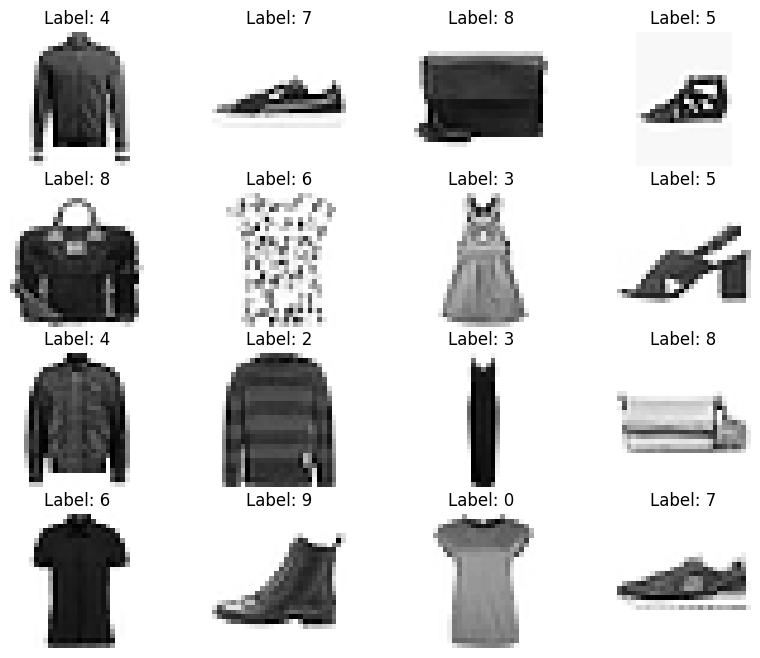

In [22]:
plt.figure(figsize=(10, 8))

for idx, n in enumerate(samples):
    plt.subplot(4, 4, idx + 1)
    plt.imshow(X_train[n].reshape(28, 28), cmap="Grays")
    plt.title("Label: " + str(y_train[n]))
    plt.axis("off")

plt.show()

In [23]:
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(1000, activation="relu"),
        tf.keras.layers.Dense(10, activation="softmax"),
    ]
)

model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │       785,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,010 (3.03 MB)

 Trainable params: 795,010 (3.03 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
import time

start_time = time.time()
hist = model.fit(
    X_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=100,
    verbose=1,
)

print("Fit time: ", time.time() - start_time)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9260 - loss: 0.1993 - val_accuracy: 0.0975 - val_loss: 7.1220
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9287 - loss: 0.1911 - val_accuracy: 0.0975 - val_loss: 7.5342
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9335 - loss: 0.1812 - val_accuracy: 0.0969 - val_loss: 8.0985
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9375 - loss: 0.1720 - val_accuracy: 0.0994 - val_loss: 8.3329
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9396 - loss: 0.1647 - val_accuracy: 0.0987 - val_loss: 8.6690
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9424 - loss: 0.1575 - val_accuracy: 0.0994 - val_loss: 9.2974
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9437 - loss: 0.1541 - val_accuracy: 0.1019 - val_loss: 10.0000
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9449 - loss: 0.1481 - val_accuracy: 0

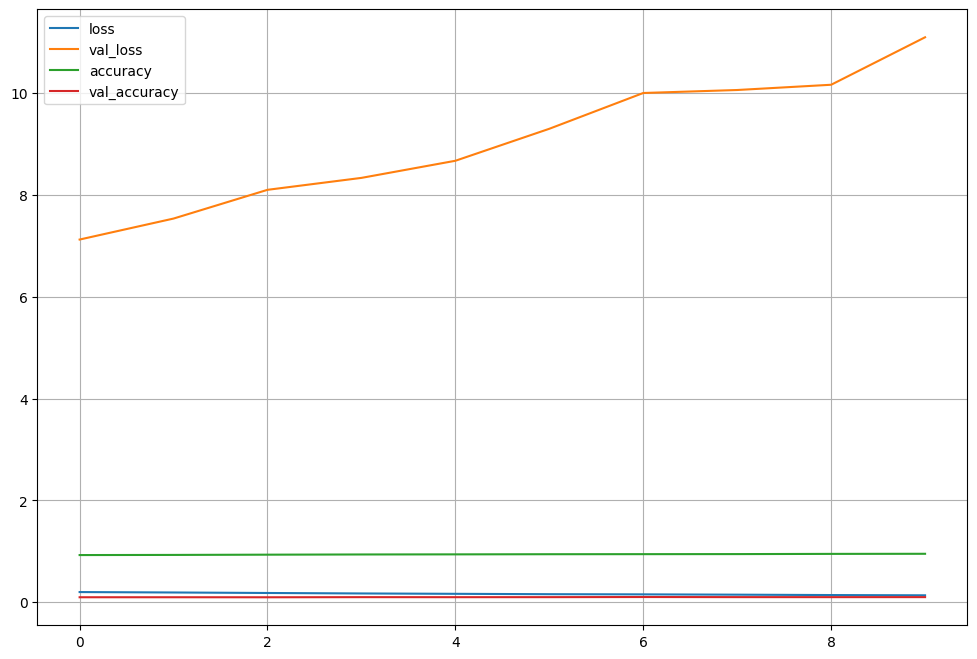

In [39]:
import matplotlib.pyplot as plt

plot_target = ["loss", "val_loss", "accuracy", "val_accuracy"]

plt.figure(figsize=(12, 8))

for each in plot_target:
    plt.plot(hist.history[each], label=each)

plt.legend()
plt.grid()
plt.show()

In [40]:
score = model.evaluate(X_test, y_test)
print("Test loss: ", score[0])
print("Test accuracy: ", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - accuracy: 0.8887 - loss: 0.3739
Test loss:  0.3739105761051178
Test accuracy:  0.888700008392334


In [41]:
import numpy as np

predicted_result = model.predict(X_test)
predicted_labels = np.argmax(predicted_result, axis=1)
predicted_labels[:10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 588us/step


array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7])

In [42]:
y_test[:10]

array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7], dtype=uint8)

In [43]:
wrong_result = []

for n in range(0, len(y_test)):
    if predicted_labels[n] != y_test[n]:
        wrong_result.append(n)

len(wrong_result)

1113

In [44]:
import random

samples = random.choices(population=wrong_result, k=16)
samples

[3232,
 1408,
 4153,
 3800,
 8774,
 851,
 9171,
 9917,
 939,
 2337,
 1207,
 5168,
 860,
 9276,
 2290,
 7239]

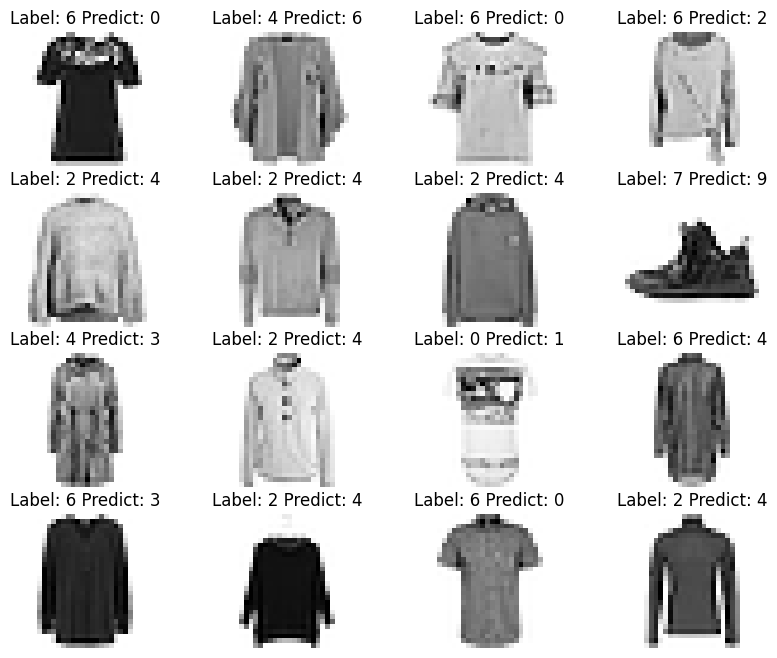

In [45]:
plt.figure(figsize=(10, 8))

for idx, n in enumerate(samples):
    plt.subplot(4, 4, idx + 1)
    plt.imshow(X_test[n].reshape(28, 28), cmap="Greys", interpolation="nearest")
    plt.title("Label: " + str(y_test[n]) + " Predict: " + str(predicted_labels[n]))
    plt.axis("off")

plt.show()